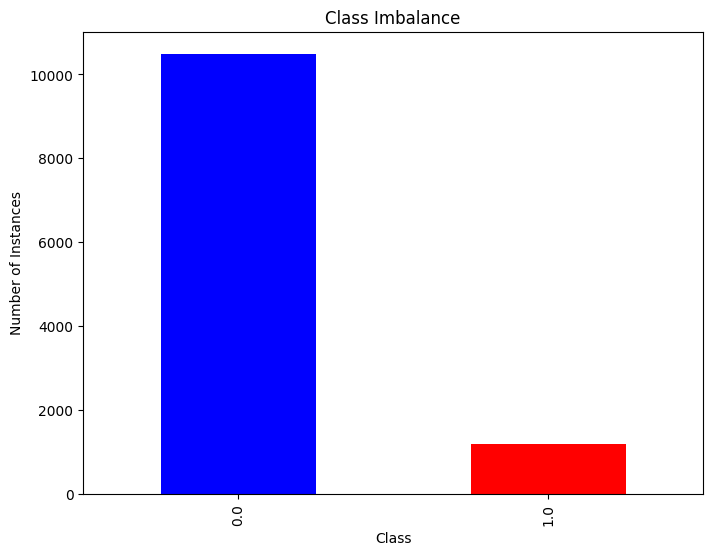

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file into a DataFrame
df = pd.read_csv('/content/heart-disease.csv')

# Assuming 'target_column' is the name of your target column
target_column = 'HeartDiseaseOrAttack'

# Count the occurrences of each class in the target column
class_counts = df['HeartDiseaseorAttack'].value_counts()

# Plotting the bar chart
plt.figure(figsize=(8, 6))
class_counts.plot(kind='bar', color=['blue', 'red'])  # Assign colors to classes
plt.xlabel('Class')
plt.ylabel('Number of Instances')
plt.title('Class Imbalance')
plt.show()


In [2]:
!pip install -U imbalanced-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.0/258.0 kB 4.5 MB/s eta 0:00:00
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.10.1
    Uninstalling imbalanced-learn-0.10.1:
      Successfully uninstalled imbalanced-learn-0.10.1


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd
import numpy as np
# Load your dataset into a DataFrame (replace 'your_file.csv' with your actual file path)
# import the heart disease dataset


# the names will be the names of each column in our pandas DataFrame
names = ['HeartDiseaseorAttack','HighBP','HighChol','CholCheck','BMI','Smoker','Stroke','Diabetes','PhysActivity','Fruits','Veggies','HvyAlcoholConsump','AnyHealthcare','NoDocbcCost',
         'GenHlth','MentHlth','PhysHlth','DiffWalk','Sex','Age','Education','Income']
# Load the heart disease dataset from a CSV file
data = pd.read_csv('/content/heart-disease.csv', names=names ,skiprows=1)

# Separate features (X) and target variable (y)
X = data.drop('HeartDiseaseorAttack', axis=1)  # Assuming 'target' is the name of the target column
y = data['HeartDiseaseorAttack']


# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define data augmentation parameters
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

# Fit the data augmentation generator to the training data
datagen.fit(X_train_scaled.reshape(-1, 21, 1, 1))  # Reshape to (num_samples, 21, 1, 1)

# Generate augmented data
augmented_data = []
batch_size = 32
num_augmented_samples = 1000  # Number of augmented samples to generate

for X_batch, y_batch in datagen.flow(X_train_scaled.reshape(-1, 21, 1, 1), y_train, batch_size=batch_size):
    augmented_data.append(X_batch)
    if len(augmented_data) * batch_size >= num_augmented_samples:
        break
X_augmented = np.concatenate(augmented_data, axis=0)
X_augmented = X_augmented.reshape(-1, X_train_scaled.shape[1])

# Reshape the augmented data back to the original shape
X_augmented = X_augmented.reshape(-1, X_train_scaled.shape[1])

# Concatenate the augmented data with the original training data
X_train = np.vstack((X_train_scaled, X_augmented))
y_train = np.hstack((y_train, y_train[:num_augmented_samples]))


# Now you can use X_train_augmented and y_train_augmented for training your model
